In [112]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [113]:
# Make some fuzzy set functions:
def trapezoidal_membership_function(domain, a, b, c, d):
    y = np.zeros_like(domain, dtype=float)
    
    # rising edge
    idx = (a < domain) & (domain < b)
    y[idx] = (domain[idx] - a) / (b - a)

    # top
    idx = (b <= domain) & (domain <= c)
    y[idx] = 1.0

    # falling edge
    idx = (c < domain) & (domain < d)
    y[idx] = (d - domain[idx]) / (d - c)

    return y


def gauss_membership_func(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

def interp_membership(domain, mf_values, x):
    """
    Equivalent to skfuzzy.interp_membership
    domain: e.g. np.linspace(...)
    mf_values: membership values on that domain
    x: crisp input
    """
    return np.interp(x, domain, mf_values)

def centroid_defuzzification(domain, aggregated_mf):
    """
    Compute centroid defuzzification (discrete version).

    domain: np.ndarray
        The universe of discourse (e.g., domain_difficulty)
    aggregated_mf: np.ndarray
        Aggregated membership values over the domain

    returns: float
        Crisp output (centroid)
    """
    numerator = np.sum(domain * aggregated_mf)
    denominator = np.sum(aggregated_mf)

    if denominator == 0:
        # no rule fired → fallback (should rarely happen)
        return np.mean(domain)

    return numerator / denominator



In [114]:
data = fetch_california_housing()
samples_temp = data.data
labels = data.target  # median house value in 100k USD

feature_names = data.feature_names
print(feature_names)

idx_inc = feature_names.index("MedInc")
idx_age = feature_names.index("HouseAge")

samples = samples_temp[:, [idx_inc, idx_age]]
inc = samples[:, 0]
age = samples[:, 1]

X_train, X_test, y_train, y_test = train_test_split(samples, labels, test_size=0.25, random_state=42)

print("X2 shape:", samples.shape)
print("Features used:", ["MedInc", "HouseAge"])
print("y range:", float(labels.min()), "to", float(labels.max()))


['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X2 shape: (20640, 2)
Features used: ['MedInc', 'HouseAge']
y range: 0.14999 to 5.00001


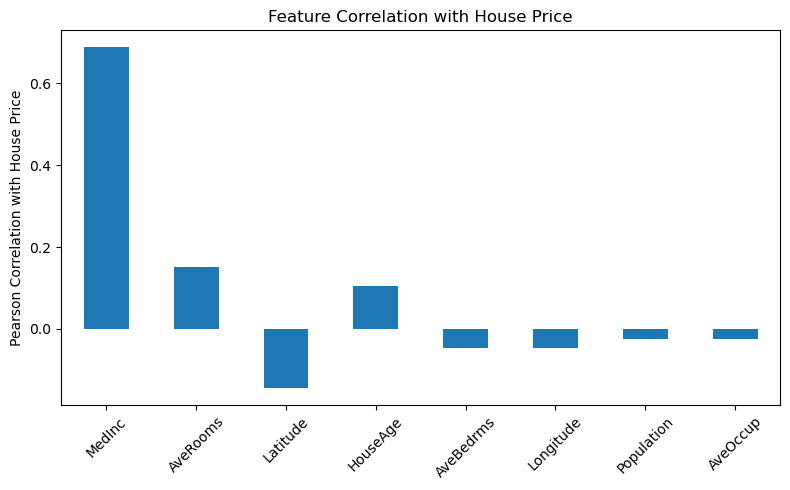

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设你已经有：
# X: feature matrix (numpy array or pandas DataFrame)
# y: target (house price)

feature_names = [
    'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
    'Population', 'AveOccup', 'Latitude', 'Longitude'
]

# 如果 X 是 numpy array，先转成 DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['HousePrice'] = y

# 计算相关系数
correlations = df.corr()['HousePrice'].drop('HousePrice')

# 按绝对值排序（重要！！）
correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
)

# 画图
plt.figure(figsize=(8, 5))
correlations.plot(kind='bar')
plt.ylabel("Pearson Correlation with House Price")
plt.title("Feature Correlation with House Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


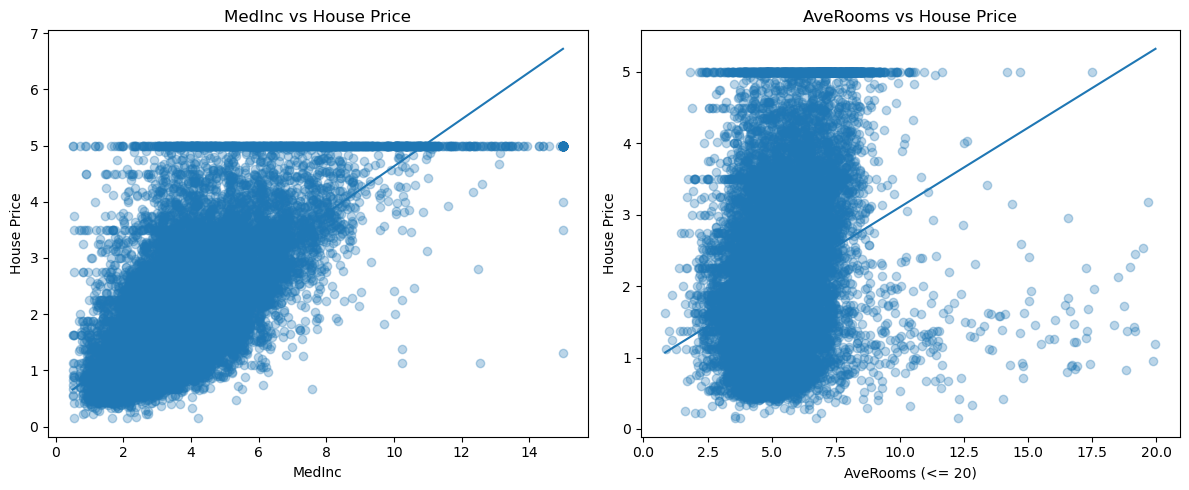

In [116]:
# 只显示 AveRooms <= 20 的样本
mask = averooms <= 20

plt.figure(figsize=(12, 5))

# MedInc
plt.subplot(1, 2, 1)
plt.scatter(medinc, house_price, alpha=0.3)
z = np.polyfit(medinc, house_price, 1)
p = np.poly1d(z)
plt.plot(np.sort(medinc), p(np.sort(medinc)))
plt.xlabel("MedInc")
plt.ylabel("House Price")
plt.title("MedInc vs House Price")

# AveRooms（限制范围）
plt.subplot(1, 2, 2)
plt.scatter(averooms[mask], house_price[mask], alpha=0.3)
z = np.polyfit(averooms[mask], house_price[mask], 1)
p = np.poly1d(z)
plt.plot(
    np.sort(averooms[mask]),
    p(np.sort(averooms[mask]))
)
plt.xlabel("AveRooms (<= 20)")
plt.ylabel("House Price")
plt.title("AveRooms vs House Price")

plt.tight_layout()
plt.show()


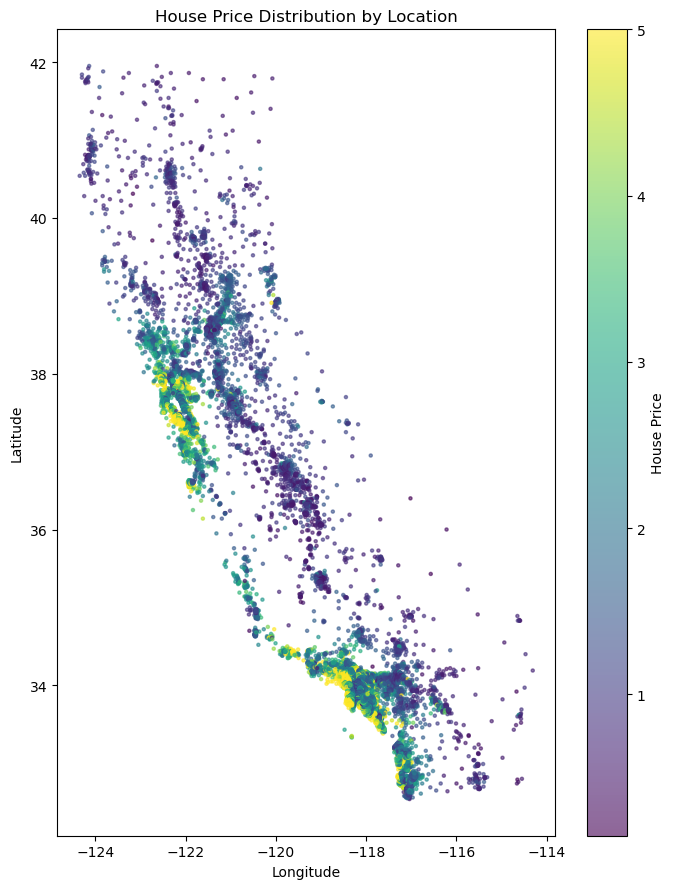

In [117]:
import matplotlib.pyplot as plt

# 假设：
# X: numpy array, shape = (N, 8)
# y: house price

LAT_IDX = 6
LON_IDX = 7

lat = X[:, LAT_IDX]
lon = X[:, LON_IDX]
price = y

plt.figure(figsize=(7, 9))

sc = plt.scatter(
    lon, lat,
    c=price,
    s=5,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Price Distribution by Location")

cbar = plt.colorbar(sc)
cbar.set_label("House Price")

plt.tight_layout()
plt.show()


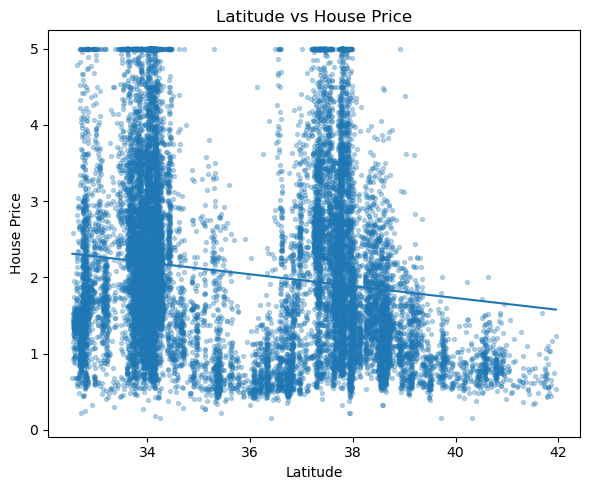

In [118]:
import matplotlib.pyplot as plt
import numpy as np

LAT_IDX = 6

latitude = X[:, LAT_IDX]
house_price = y

plt.figure(figsize=(6, 5))
plt.scatter(latitude, house_price, alpha=0.3, s=8)

# 加一条趋势线（只是辅助观察）
z = np.polyfit(latitude, house_price, 1)
p = np.poly1d(z)
x_sorted = np.sort(latitude)
plt.plot(x_sorted, p(x_sorted))

plt.xlabel("Latitude")
plt.ylabel("House Price")
plt.title("Latitude vs House Price")
plt.tight_layout()
plt.show()


In [119]:
# Helper: get robust boundaries from percentiles
def p(x, q):
    return float(np.percentile(x, q))

inc_all = X_train[:, 0]
age_all = X_train[:, 1]
y_all   = y_train

# Domains (robust ranges)
domain_inc = np.linspace(p(inc_all, 1), p(inc_all, 99), 401)
domain_age = np.linspace(p(age_all, 1), p(age_all, 99), 401)
domain_price = np.linspace(p(y_all, 1), p(y_all, 99), 401)

# --- Input membership: Income (low/med/high) ---
inc_lo = trapezoidal_membership_function(domain_inc, domain_inc[0], domain_inc[0], p(inc_all, 20), p(inc_all, 40))
inc_md = trapezoidal_membership_function(domain_inc, p(inc_all, 30), p(inc_all, 45), p(inc_all, 55), p(inc_all, 70))
inc_hi = trapezoidal_membership_function(domain_inc, p(inc_all, 60), p(inc_all, 80), domain_inc[-1], domain_inc[-1])

# --- Input membership: HouseAge (new/mid/old) ---
age_new = trapezoidal_membership_function(domain_age, domain_age[0], domain_age[0], p(age_all, 20), p(age_all, 40))
age_mid = trapezoidal_membership_function(domain_age, p(age_all, 30), p(age_all, 45), p(age_all, 55), p(age_all, 70))
age_old = trapezoidal_membership_function(domain_age, p(age_all, 60), p(age_all, 80), domain_age[-1], domain_age[-1])

# --- Output membership: Price (low/med/high) ---
price_lo = trapezoidal_membership_function(domain_price, domain_price[0], domain_price[0], p(y_all, 25), p(y_all, 45))
price_md = trapezoidal_membership_function(domain_price, p(y_all, 35), p(y_all, 48), p(y_all, 52), p(y_all, 65))
price_hi = trapezoidal_membership_function(domain_price, p(y_all, 55), p(y_all, 75), domain_price[-1], domain_price[-1])


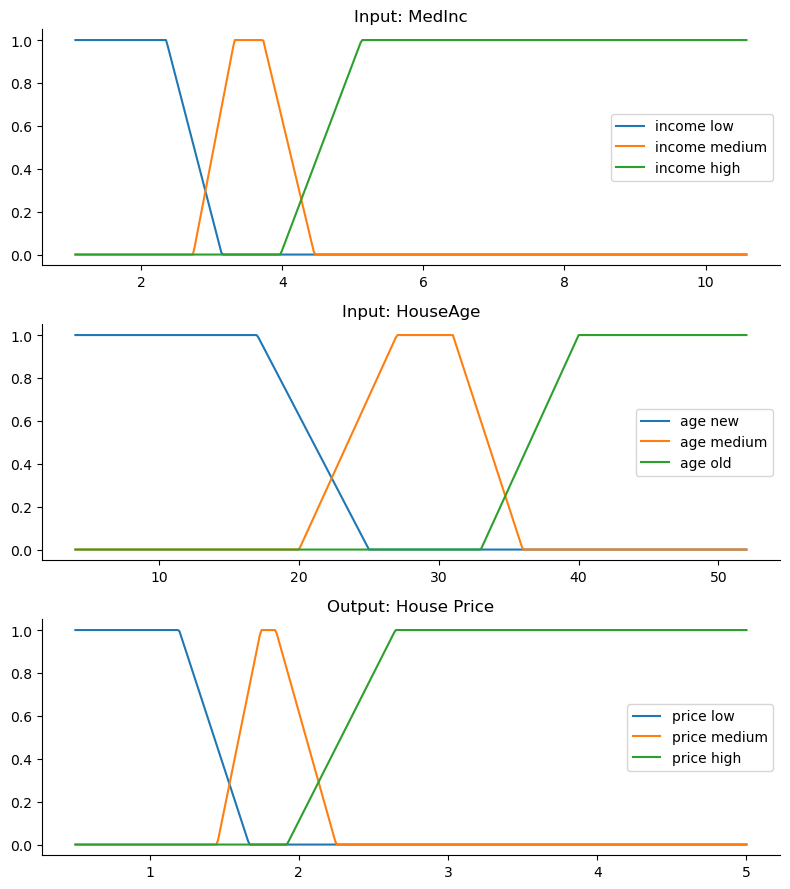

In [120]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8, 9))

axes[0].plot(domain_inc, inc_lo, label="income low")
axes[0].plot(domain_inc, inc_md, label="income medium")
axes[0].plot(domain_inc, inc_hi, label="income high")
axes[0].set_title("Input: MedInc")
axes[0].legend()

axes[1].plot(domain_age, age_new, label="age new")
axes[1].plot(domain_age, age_mid, label="age medium")
axes[1].plot(domain_age, age_old, label="age old")
axes[1].set_title("Input: HouseAge")
axes[1].legend()

axes[2].plot(domain_price, price_lo, label="price low")
axes[2].plot(domain_price, price_md, label="price medium")
axes[2].plot(domain_price, price_hi, label="price high")
axes[2].set_title("Output: House Price")
axes[2].legend()

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [121]:
def housing_fls_predict_one(inc_value, age_value, aggregation="max"):
    # ---- fuzzification ----
    inc_lo_v = interp_membership(domain_inc, inc_lo, inc_value)
    inc_md_v = interp_membership(domain_inc, inc_md, inc_value)
    inc_hi_v = interp_membership(domain_inc, inc_hi, inc_value)

    age_new_v = interp_membership(domain_age, age_new, age_value)
    age_mid_v = interp_membership(domain_age, age_mid, age_value)
    age_old_v = interp_membership(domain_age, age_old, age_value)

    # ---- rule firing (AND=min) ----
    r1 = inc_lo_v
    r2 = inc_md_v
    r3 = inc_hi_v
    r4 = min(inc_lo_v, age_old_v)
    r5 = min(inc_hi_v, age_new_v)
    r6 = min(inc_md_v, age_old_v)

    # ---- implication (clipping) ----
    chop1 = np.minimum(price_lo, r1)
    chop2 = np.minimum(price_md, r2)
    chop3 = np.minimum(price_hi, r3)
    chop4 = np.minimum(price_lo, r4)
    chop5 = np.minimum(price_hi, r5)
    chop6 = np.minimum(price_md, r6)

    # ---- aggregation ----
    if aggregation == "max":
        aggregated = np.maximum.reduce([chop1, chop2, chop3, chop4, chop5, chop6])
    elif aggregation == "sum":
        aggregated = np.sum([chop1, chop2, chop3, chop4, chop5, chop6], axis=0)
    else:
        raise ValueError("aggregation must be 'max' or 'sum'")

    # ---- defuzzification ----
    y_hat = centroid_defuzzification(domain_price, aggregated)

    return y_hat, (r1, r2, r3, r4, r5, r6), aggregated


In [122]:
y_pred = []
for inc_value, age_value in X_test:
    pred, rules, aggregated = housing_fls_predict_one(inc_value, age_value, aggregation="max")
    y_pred.append(pred)

y_pred = np.array(y_pred)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2  = r2_score(y_test, y_pred)

print("Housing FLS Regression (2 inputs: MedInc, HouseAge)")
print(f"MSE = {mse:.4f}")
print(f"MAE = {mae:.4f}")
print(f"R^2 = {r2:.4f}")


Housing FLS Regression (2 inputs: MedInc, HouseAge)
MSE = 1.0183
MAE = 0.7735
R^2 = 0.2304


Sample inputs:
  MedInc   = 1.6812
  HouseAge = 25.0
Predicted price (100k USD units): 0.97388098199751
Rule firing: (1.0, 0.0, 0.0, 0.0, 0.0, 0.0)


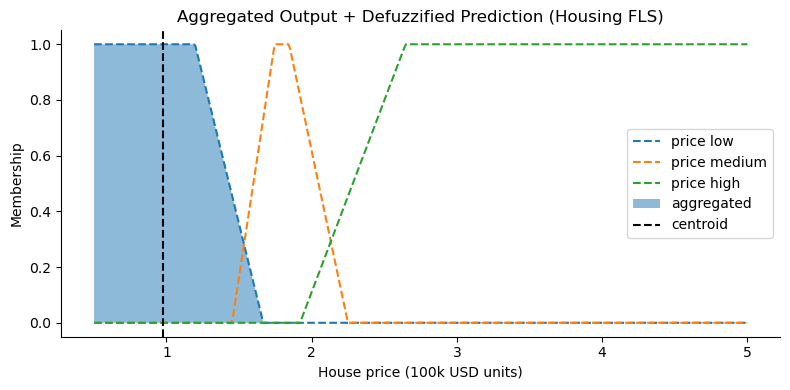

In [123]:
import matplotlib.pyplot as plt

# pick one test sample
inc_value, age_value = X_test[0]
pred, rules, aggregated = housing_fls_predict_one(inc_value, age_value, aggregation="max")

print("Sample inputs:")
print("  MedInc   =", inc_value)
print("  HouseAge =", age_value)
print("Predicted price (100k USD units):", pred)
print("Rule firing:", rules)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(domain_price, price_lo, '--', label="price low")
ax.plot(domain_price, price_md, '--', label="price medium")
ax.plot(domain_price, price_hi, '--', label="price high")
ax.fill_between(domain_price, aggregated, alpha=0.5, label="aggregated")
ax.axvline(pred, color="k", linestyle="--", label="centroid")

ax.set_title("Aggregated Output + Defuzzified Prediction (Housing FLS)")
ax.set_xlabel("House price (100k USD units)")
ax.set_ylabel("Membership")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
